# 01 - Preparación de Datos: Proyecto F1 (CRISP-DM)

**Curso:** Minería de Datos  
**Dataset:** `f1_final_dataset.csv`  
**Objetivo:** Preparar datos para modelos descriptivos (clustering) y predictivos (clasificación) sobre finalización de carrera (`finished`).

---


## 0. Configuración e Imports

Cargamos las librerías estándar necesarias y fijamos semillas para garantizar reproducibilidad.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
import pickle
import warnings
warnings.filterwarnings('ignore')

# Reproducibilidad
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_style('whitegrid')

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


## Fase 1: Entendimiento del Negocio

### Contexto Fórmula 1
La Fórmula 1 es la máxima categoría del automovilismo internacional. Cada temporada consta de múltiples Grandes Premios donde pilotos y constructores compiten por puntos. La predicción de si un piloto **terminará la carrera** (`finished = 1`) o **abandonará** (`finished = 0`) es crítica para:
- Estrategias de apuestas y fantasy sports.
- Optimización de decisiones de equipo (neumáticos, paradas).
- Análisis de riesgo para patrocinadores.

### Problema de Minería de Datos
- **Problema principal:** Predicción de finalización de carrera (clasificación binaria).
- **Objetivos descriptivos:** Segmentar pilotos/constructores mediante clustering para identificar perfiles de riesgo.
- **Objetivos predictivos:** Construir modelos de clasificación que estimen la probabilidad de terminar la carrera.

### Tabla de Diseño de Solución

| Problema | Tipo de Minería | Tipo de Análisis | Tipo de Aprendizaje | Requerimiento Datos | Métodos | Evaluación |
|---|---|---|---|---|---|---|
| ¿El piloto terminará la carrera? | Clasificación | Predictivo | Supervisado | Histórico de carreras con resultado finished | Regresión Logística, Random Forest, XGBoost, SVM | Accuracy, Precision, Recall, F1, ROC-AUC |
| ¿Existen perfiles de riesgo entre pilotos? | Clustering | Descriptivo | No supervisado | Estadísticas agregadas por piloto/constructor | K-Means, DBSCAN, Jerárquico | Silhouette, Inercia, Análisis visual |

### Línea Base (Baseline)
- **P = 60%**: Se espera que cualquier modelo predictivo supere el 60% de accuracy para considerarse útil.
- La clase mayoritaria (`finished = 0`) representa ~74.7%, por lo que un clasificador trivial que siempre prediga "no termina" obtendría ~74.7% de accuracy. Esto evidencia la necesidad de métricas orientadas a clase minoritaria (F1, ROC-AUC).

## Fase 2: Entendimiento de los Datos

### 2.1 Carga del Dataset

In [2]:
# Ruta del dataset
DATA_PATH = '/home/creep/workshop/proyecto-mineria/f1_final_dataset.csv'
OUTPUT_DIR = '/home/creep/workshop/proyecto-mineria/output'

# Crear directorio de salida si no existe
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Carga
df = pd.read_csv(DATA_PATH)
print(f"Dimensiones del dataset: {df.shape}")
print(f"Total de filas: {df.shape[0]:,}")
print(f"Total de columnas: {df.shape[1]}")
df.head()

# Eliminar 'laps' (variable conocida después de la carrera)
df = df.drop(columns=['laps'])
print(f"Columna 'laps' eliminada. Dimensiones actualizadas: {df.shape}")

Dimensiones del dataset: (23777, 30)
Total de filas: 23,777
Total de columnas: 30
Columna 'laps' eliminada. Dimensiones actualizadas: (23777, 29)


### 2.2 Diccionario de Datos

| Variable | Descripción | Tipo |
|---|---|---|
| `grid` | Posición de salida en parrilla | Numérico (int) |
| `driver_age` | Edad del piloto (años) | Numérico (float) |
| `driver_race_count` | Carreras previas del piloto | Numérico (int) |
| `driver_prev_finish_rate` | Tasa histórica de finalización del piloto | Numérico (float) |
| `driver_last5_finish_rate` | Tasa de finalización en últimas 5 carreras | Numérico (float) |
| `constructor_race_count` | Carreras previas del constructor | Numérico (int) |
| `constructor_prev_finish_rate` | Tasa histórica de finalización del constructor | Numérico (float) |
| `constructor_prev_avg_grid` | Grid promedio histórico del constructor | Numérico (float) |
| `constructor_last5_finish_rate` | Tasa de finalización del constructor (últimas 5) | Numérico (float) |
| `circuit_finish_rate` | Tasa de finalización histórica en el circuito | Numérico (float) |
| `circuit_avg_grid` | Grid promedio histórico en el circuito | Numérico (float) |
| `race_month` | Mes de la carrera (1-12) | Numérico (int) |
| `race_day_of_year` | Día del año de la carrera (1-366) | Numérico (int) |
| `season_progress` | Progreso de la temporada (0-1) | Numérico (float) |
| `q1_seconds` | Tiempo en Q1 (segundos) | Numérico (float) |
| `q2_seconds` | Tiempo en Q2 (segundos) | Numérico (float) |
| `q3_seconds` | Tiempo en Q3 (segundos) | Numérico (float) |
| `best_q_time` | Mejor tiempo de clasificación (segundos) | Numérico (float) |
| `grid_normalized` | Grid normalizado (0-1) | Numérico (float) |
| `has_qualifying` | Indicador si hubo clasificación (0/1) | Numérico (int) |
| `front_row_start` | Indicador salida en primera fila (0/1) | Numérico (int) |
| `top10_start` | Indicador salida en top 10 (0/1) | Numérico (int) |
| `year` | Año de la carrera | Numérico (int) |
| `round` | Número de ronda en la temporada | Numérico (int) |
| `driver_nationality_encoded` | Nacionalidad del piloto (encoded) | Numérico (int) |
| `constructor_nationality_encoded` | Nacionalidad del constructor (encoded) | Numérico (int) |
| `circuit_country_encoded` | País del circuito (encoded) | Numérico (int) |
| `circuitRef_encoded` | Referencia del circuito (encoded) | Numérico (int) |
| `finished` | **Variable objetivo**: 1 = terminó, 0 = abandonó | Numérico (int) |

### 2.3 Reglas de Calidad desde el Negocio

Antes de cualquier análisis, establecemos reglas de integridad basadas en el dominio de la F1:

1. **`driver_age`**: Debe estar entre 17 y 60 años (límites reglamentarios históricos y razonables).
2. **`grid`**: Debe estar entre 0 y 34 (máximo de entradas histórico en F1).
3. **`finished`**: Solo valores {0, 1}.
4. **`laps`**: Eliminada del dataset (conocida post-carrera).
5. **`year`**: Entre 1950 y 2017 según el dataset.
6. **Tasas (`*_finish_rate`)**: Deben estar en [0, 1].
7. **`q1_seconds`, `q2_seconds`, `q3_seconds`, `best_q_time`**: En años sin clasificación moderna pueden presentar valores imputados constantes.

In [3]:
# Verificación de reglas de calidad
quality_issues = []

if not df['driver_age'].between(17, 60).all():
    quality_issues.append(f"driver_age fuera de rango: {(~df['driver_age'].between(17,60)).sum()} registros")

if not df['grid'].between(0, 34).all():
    quality_issues.append(f"grid fuera de rango: {(~df['grid'].between(0,34)).sum()} registros")

if not df['finished'].isin([0,1]).all():
    quality_issues.append("finished contiene valores distintos de 0/1")


rate_cols = [c for c in df.columns if 'finish_rate' in c]
for col in rate_cols:
    if not df[col].between(0,1).all():
        quality_issues.append(f"{col} fuera de [0,1]")

if quality_issues:
    print("Problemas de calidad encontrados:")
    for issue in quality_issues:
        print(f"  - {issue}")
else:
    print("Todas las reglas de calidad del negocio se cumplen.")

Todas las reglas de calidad del negocio se cumplen.


### 2.4 Estadísticas Descriptivas Detalladas

In [4]:
# Estadísticas descriptivas completas
desc = df.describe().T
desc['missing'] = df.isnull().sum()
desc['missing_pct'] = (df.isnull().sum() / len(df)) * 100
desc['skewness'] = df.skew(numeric_only=True)
desc['kurtosis'] = df.kurtosis(numeric_only=True)
desc = desc[['count', 'missing', 'missing_pct', 'mean', 'std', 'min', '25%', '50%', '75%', 'max', 'skewness', 'kurtosis']]
print(desc.round(4).to_string())

                                   count  missing  missing_pct       mean       std        min        25%        50%        75%        max  skewness   kurtosis
grid                             23777.0        0          0.0    11.2703    7.3464     0.0000     5.0000    11.0000    17.0000    34.0000    0.1856    -0.9560
driver_age                       23777.0        0          0.0    30.1748    5.0984    17.4538    26.4641    29.6454    33.3771    53.2621    0.5892     0.4573
driver_race_count                23777.0        0          0.0    59.0434   59.4337     1.0000    13.0000    39.0000    86.0000   326.0000    1.4551     1.9411
driver_prev_finish_rate          23777.0        0          0.0     0.2157    0.2173     0.0000     0.0000     0.1579     0.3563     1.0000    0.8699    -0.0571
driver_last5_finish_rate         23777.0        0          0.0     0.2505    0.3056     0.0000     0.0000     0.2000     0.4000     1.0000    0.9885    -0.2218
constructor_race_count           23777.0

### 2.5 Distribución de la Variable Objetivo (`finished`)

La variable objetivo presenta un desbalance significativo: ~74.7% de abandonos (clase 0) vs ~25.3% de finalizaciones (clase 1). Este desbalance será abordado explícitamente en la fase de preparación.

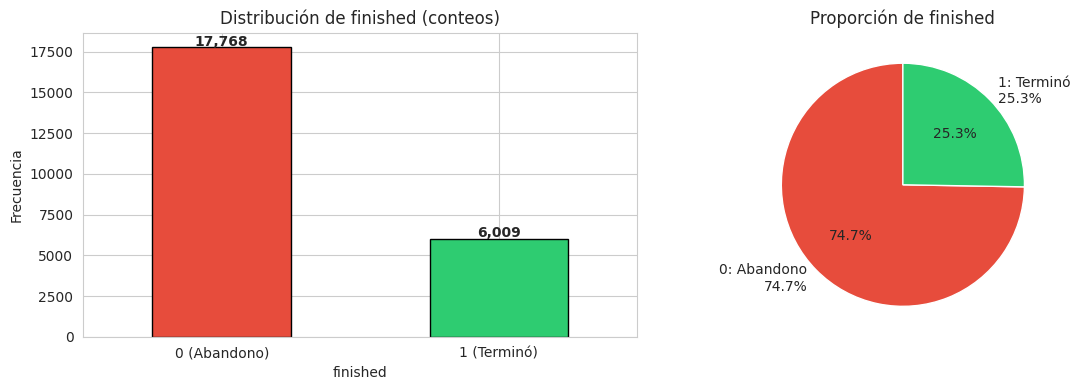

Clase 0 (Abandono): 17,768 registros (74.73%)
Clase 1 (Terminó):  6,009 registros (25.27%)


In [5]:
# Distribución de finished
finished_counts = df['finished'].value_counts().sort_index()
finished_pct = df['finished'].value_counts(normalize=True).sort_index() * 100

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Barras
finished_counts.plot(kind='bar', ax=ax[0], color=['#e74c3c', '#2ecc71'], edgecolor='black')
ax[0].set_title('Distribución de finished (conteos)')
ax[0].set_xlabel('finished')
ax[0].set_ylabel('Frecuencia')
ax[0].set_xticklabels(['0 (Abandono)', '1 (Terminó)'], rotation=0)
for i, v in enumerate(finished_counts.values):
    ax[0].text(i, v + 100, f"{v:,}", ha='center', fontweight='bold')

# Pie
ax[1].pie(finished_counts, labels=[f'0: Abandono\n{finished_pct[0]:.1f}%', f'1: Terminó\n{finished_pct[1]:.1f}%'],
          colors=['#e74c3c', '#2ecc71'], autopct='%1.1f%%', startangle=90)
ax[1].set_title('Proporción de finished')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/distribucion_finished.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Clase 0 (Abandono): {finished_counts[0]:,} registros ({finished_pct[0]:.2f}%)")
print(f"Clase 1 (Terminó):  {finished_counts[1]:,} registros ({finished_pct[1]:.2f}%)")

### 2.6 Referencia al Reporte de Pandas Profiling

Se generó previamente un reporte exploratorio exhaustivo con **pandas-profiling** (o **ydata-profiling**). Este reporte incluye:
- Alertas de tipos de datos, cardinalidad y correlaciones.
- Distribuciones completas de cada variable.
- Interacciones y matriz de correlaciones.

**Ubicación:** `../output/pandas_profiling_report.html`

Recomendación: revisar dicho reporte para identificar anomalías adicionales antes de la limpieza.

### 2.6b Perfilamiento con ydata-profiling

Se genera un reporte exhaustivo con **ydata-profiling** para documentar la calidad, distribuciones, correlaciones y alertas del dataset. Este reporte se almacena en el repositorio para consulta.

In [6]:
from ydata_profiling import ProfileReport

profile = ProfileReport(df, title='F1 Dataset - ydata-profiling Report', explorative=True)
report_path = f'{OUTPUT_DIR}/ydata_profiling_report.html'
profile.to_file(report_path)
print(f'Reporte ydata-profiling guardado en: {report_path}')

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Summarize dataset:   0%|          | 0/34 [00:00<?, ?it/s, Describe variable: grid]

Summarize dataset:   0%|          | 0/34 [00:00<?, ?it/s, Describe variable: driver_age]

Summarize dataset:   0%|          | 0/34 [00:00<?, ?it/s, Describe variable: driver_prev_finish_rate]

Summarize dataset:   0%|          | 0/34 [00:00<?, ?it/s, Describe variable: driver_last5_finish_rate]

...

Render HTML: 100%|██████████| 1/1 [00:01<00:00,  1.27s/it]

Render HTML: 100%|██████████| 1/1 [00:01<00:00,  1.27s/it]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file: 100%|██████████| 1/1 [00:00<00:00, 48.50it/s]

Reporte ydata-profiling guardado en: /home/creep/workshop/proyecto-mineria/output/ydata_profiling_report.html


## Fase 3: Preparación de Datos

### 3.1 Integración

Verificamos si existen múltiples fuentes de datos que deban unirse.

In [7]:
# El dataset proviene de un único archivo CSV consolidado.
# No se requiere integración de múltiples fuentes.
print("Fuente única: f1_final_dataset.csv")
print(f"Registros: {len(df):,} | Variables: {df.shape[1]}")
print("No se requiere integración adicional.")

Fuente única: f1_final_dataset.csv
Registros: 23,777 | Variables: 29
No se requiere integración adicional.


### 3.2 Selección de Variables Iniciales

Documentamos todas las variables disponibles antes de cualquier eliminación. El dataset contiene 29 features más la variable objetivo.

In [8]:
features_iniciales = [c for c in df.columns if c != 'finished']
print(f"Variables iniciales ({len(features_iniciales)}):")
for i, col in enumerate(features_iniciales, 1):
    print(f"{i:2d}. {col}")

Variables iniciales (28):
 1. grid
 2. driver_age
 3. driver_race_count
 4. driver_prev_finish_rate
 5. driver_last5_finish_rate
 6. constructor_race_count
 7. constructor_prev_finish_rate
 8. constructor_prev_avg_grid
 9. constructor_last5_finish_rate
10. circuit_finish_rate
11. circuit_avg_grid
12. race_month
13. race_day_of_year
14. season_progress
15. q1_seconds
16. q2_seconds
17. q3_seconds
18. best_q_time
19. grid_normalized
20. has_qualifying
21. front_row_start
22. top10_start
23. year
24. round
25. driver_nationality_encoded
26. constructor_nationality_encoded
27. circuit_country_encoded
28. circuitRef_encoded


### 3.3 Estadística Descriptiva: Resumen Completo

Presentamos un resumen estructurado por tipo de variable y función.

In [9]:
# Clasificación conceptual de variables
var_groups = {
    'Piloto (performance histórica)': ['driver_age', 'driver_race_count', 'driver_prev_finish_rate', 'driver_last5_finish_rate'],
    'Constructor (performance histórica)': ['constructor_race_count', 'constructor_prev_finish_rate', 'constructor_prev_avg_grid', 'constructor_last5_finish_rate'],
    'Circuito': ['circuit_finish_rate', 'circuit_avg_grid'],
    'Calendario/Temporada': ['race_month', 'race_day_of_year', 'season_progress', 'year', 'round'],
    'Clasificación (qualifying)': ['q1_seconds', 'q2_seconds', 'q3_seconds', 'best_q_time', 'grid', 'grid_normalized', 'has_qualifying', 'front_row_start', 'top10_start'],
    'Codificaciones categóricas': ['driver_nationality_encoded', 'constructor_nationality_encoded', 'circuit_country_encoded', 'circuitRef_encoded']
}

for group, cols in var_groups.items():
    print('\n' + '='*60)
    print(f"Grupo: {group}")
    print('='*60)
    display(df[cols].describe().T.round(4))


Grupo: Piloto (performance histórica)


,count,mean,std,min,25%,50%,75%,max
driver_age,23777.0,30.1748,5.0984,17.4538,26.4641,29.6454,33.3771,53.2621
driver_race_count,23777.0,59.0434,59.4337,1.0000,13.0000,39.0000,86.0000,326.0000
driver_prev_finish_rate,23777.0,0.2157,0.2173,0.0000,0.0000,0.1579,0.3563,1.0000
driver_last5_finish_rate,23777.0,0.2505,0.3056,0.0000,0.0000,0.2000,0.4000,1.0000



Grupo: Constructor (performance histórica)


,count,mean,std,min,25%,50%,75%,max
constructor_race_count,23777.0,347.5349,417.1877,1.0,60.0000,187.0000,469.0000,2140.0
constructor_prev_finish_rate,23777.0,0.2208,0.1777,0.0,0.0625,0.2059,0.3548,1.0
constructor_prev_avg_grid,23777.0,10.9735,4.1020,0.0,7.6481,10.5018,13.6674,32.0
constructor_last5_finish_rate,23777.0,0.2516,0.2989,0.0,0.0000,0.2000,0.4000,1.0



Grupo: Circuito


...

,count,mean,std,min,25%,50%,75%,max
race_month,23777.0,6.7598,2.3706,1.0000,5.0000,7.0000,9.0000,12.0
race_day_of_year,23777.0,190.0793,71.9059,1.0000,139.0000,192.0000,250.0000,363.0
season_progress,23777.0,0.5352,0.2871,0.0476,0.2857,0.5333,0.7857,1.0
year,23777.0,1987.6751,17.9722,1950.0000,1975.0000,1989.0000,2003.0000,2017.0
round,23777.0,8.1699,4.7890,1.0000,4.0000,8.0000,12.0000,21.0



Grupo: Clasificación (qualifying)


,count,mean,std,min,25%,50%,75%,max
q1_seconds,23777.0,88.2726,9.1187,65.064,87.6090,87.6090,87.6090,1002.640
q2_seconds,23777.0,89.7959,4.6220,64.316,89.8240,89.8240,89.8240,132.470
q3_seconds,23777.0,88.8376,3.6132,64.251,88.7805,88.7805,88.7805,129.776
best_q_time,23777.0,87.8706,9.0334,64.251,87.2640,87.2640,87.2640,1002.640
grid,23777.0,11.2703,7.3464,0.000,5.0000,11.0000,17.0000,34.000
grid_normalized,23777.0,0.4862,0.3070,0.000,0.2222,0.5000,0.7500,1.000
has_qualifying,23777.0,0.3111,0.4630,0.000,0.0000,0.0000,1.0000,1.000
front_row_start,23777.0,0.1484,0.3555,0.000,0.0000,0.0000,0.0000,1.000
top10_start,23777.0,0.4789,0.4996,0.000,0.0000,0.0000,1.0000,1.000



Grupo: Codificaciones categóricas


,count,mean,std,min,25%,50%,75%,max
driver_nationality_encoded,23777.0,15.4850,9.8112,0.0,8.0,17.0,23.0,40.0
constructor_nationality_encoded,23777.0,8.7457,5.1044,0.0,5.0,5.0,14.0,23.0
circuit_country_encoded,23777.0,15.1091,9.3659,0.0,7.0,13.0,24.0,31.0
circuitRef_encoded,23777.0,39.7683,18.8570,0.0,25.0,39.0,59.0,71.0


### 3.4 Limpieza de Atípicos (Outliers)

Utilizamos el método **IQR (Rango Intercuartílico)** para detectar outliers en variables continuas. Una observación se considera atípica si cae fuera de $[Q1 - 1.5 \times IQR, Q3 + 1.5 \times IQR]$.

**Observación importante:** Las variables `q1_seconds`, `q2_seconds`, `q3_seconds` y `best_q_time` presentan **valores imputados constantes** en años antiguos sin sistema de clasificación moderno. Estos no son atípicos técnicos sino artefactos de imputación. Los documentamos pero no los eliminamos como outliers tradicionales, ya que contienen información (ausencia de qualifying real) codificada como constante.

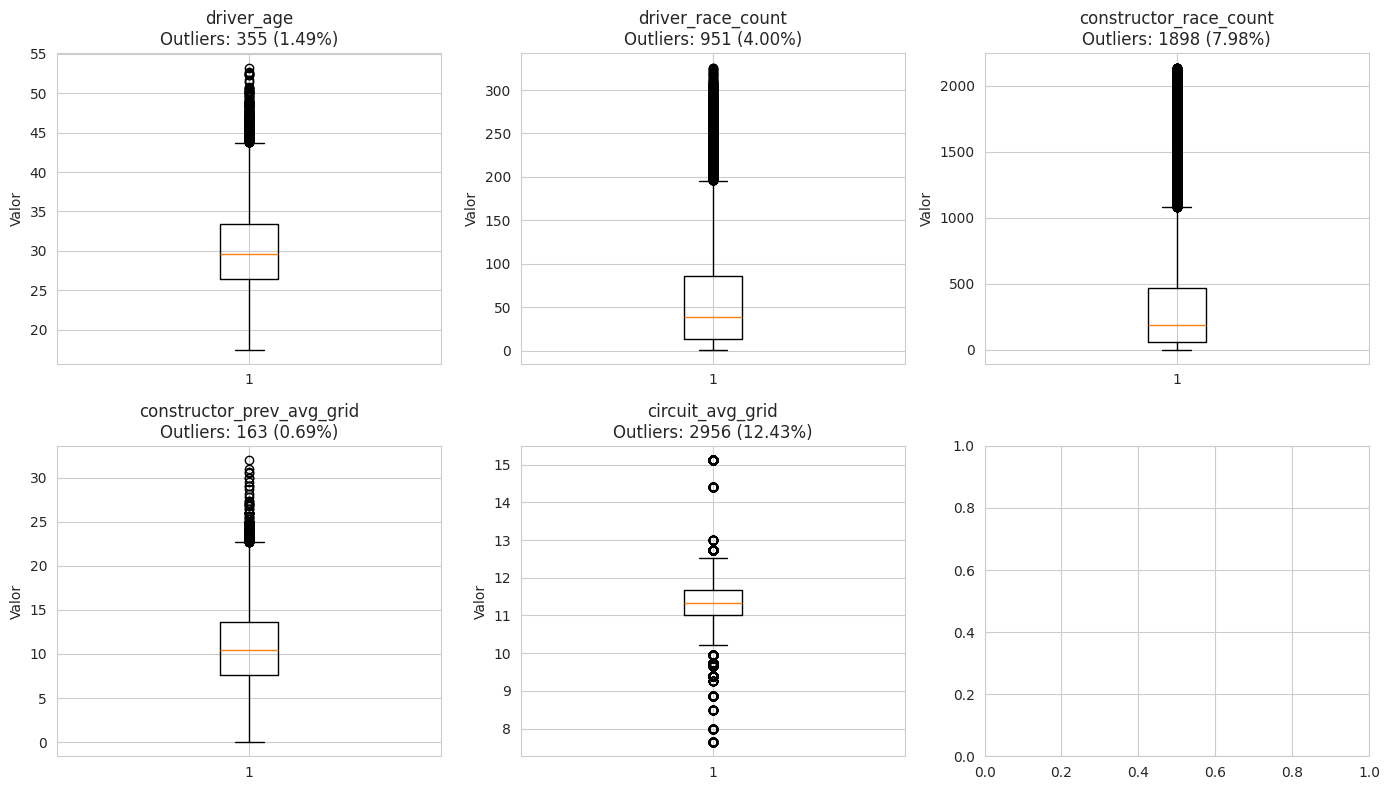

                 variable  n_outliers  pct_outliers  lower_bound  upper_bound     action
               driver_age         355          1.49        16.09        43.75 winsorizar
        driver_race_count         951          4.00       -96.50       195.50 winsorizar
   constructor_race_count        1898          7.98      -553.50      1082.50 winsorizar
constructor_prev_avg_grid         163          0.69        -1.38        22.70 winsorizar
         circuit_avg_grid        2956         12.43        10.04        12.66 winsorizar


In [10]:
# Variables continuas para análisis de outliers
continuous_vars = ['driver_age', 'driver_race_count', 'constructor_race_count',
                   'constructor_prev_avg_grid', 'circuit_avg_grid']

outlier_summary = []
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for idx, col in enumerate(continuous_vars):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outlier_mask = (df[col] < lower) | (df[col] > upper)
    n_outliers = outlier_mask.sum()
    pct_outliers = n_outliers / len(df) * 100
    
    outlier_summary.append({
        'variable': col,
        'n_outliers': n_outliers,
        'pct_outliers': round(pct_outliers, 2),
        'lower_bound': round(lower, 2),
        'upper_bound': round(upper, 2),
        'action': 'winsorizar' if pct_outliers > 0 else 'ninguna'
    })
    
    # Boxplot
    axes[idx].boxplot(df[col], vert=True)
    axes[idx].set_title(f'{col}\nOutliers: {n_outliers} ({pct_outliers:.2f}%)')
    axes[idx].set_ylabel('Valor')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/outliers_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

outlier_df = pd.DataFrame(outlier_summary)
print(outlier_df.to_string(index=False))

In [11]:
# Documentar valores constantes imputados en qualifying
qual_cols = ['q1_seconds', 'q2_seconds', 'q3_seconds', 'best_q_time']
print("Análisis de valores 'constantes' en tiempos de clasificación:")
for col in qual_cols:
    top_val = df[col].value_counts().iloc[0]
    top_pct = top_val / len(df) * 100
    print(f"  {col}: valor más frecuente aparece {top_val:,} veces ({top_pct:.1f}%) — imputación histórica.")

Análisis de valores 'constantes' en tiempos de clasificación:
  q1_seconds: valor más frecuente aparece 16,382 veces (68.9%) — imputación histórica.
  q2_seconds: valor más frecuente aparece 20,127 veces (84.6%) — imputación histórica.
  q3_seconds: valor más frecuente aparece 21,599 veces (90.8%) — imputación histórica.
  best_q_time: valor más frecuente aparece 16,381 veces (68.9%) — imputación histórica.


In [12]:
# Tratamiento: Winsorización (limitar al percentil 1% y 99%)
# Aplicamos winsorización suave para no perder registros
df_clean = df.copy()

winsorize_cols = ['driver_age', 'constructor_race_count']
for col in winsorize_cols:
    lower_p = df_clean[col].quantile(0.01)
    upper_p = df_clean[col].quantile(0.99)
    original_min = df_clean[col].min()
    original_max = df_clean[col].max()
    df_clean[col] = df_clean[col].clip(lower=lower_p, upper=upper_p)
    print(f"{col}: [{original_min:.2f}, {original_max:.2f}] -> [{df_clean[col].min():.2f}, {df_clean[col].max():.2f}]")

# Nota: no winsorizamos tasas ni qualifying por ser artefactos semánticos
print("\nWinsorización aplicada. Registros preservados:", len(df_clean))

driver_age: [17.45, 53.26] -> [20.70, 44.76]
constructor_race_count: [1.00, 2140.00] -> [2.00, 1902.24]

Winsorización aplicada. Registros preservados: 23777


### 3.5 Limpieza de Nulos

Verificamos completitud del dataset.

In [13]:
nulls = df_clean.isnull().sum()
null_pct = (nulls / len(df_clean)) * 100
null_report = pd.DataFrame({'nulos': nulls, 'pct': null_pct})
null_report = null_report[null_report['nulos'] > 0].sort_values('nulos', ascending=False)

if null_report.empty:
    print("No se encontraron valores nulos en ninguna variable.")
    print("Completitud del dataset: 100%")
else:
    print(null_report)


No se encontraron valores nulos en ninguna variable.
Completitud del dataset: 100%


### 3.6 Análisis de Correlaciones para Redundancia

Calculamos la **matriz de correlación de Pearson** entre todas las variables numéricas. Aplicamos dos criterios de eliminación:

1. **Redundancia entre features**: Si dos variables tienen $|r| > 0.8$, eliminamos una.
2. **Irrelevancia con el target**: Si $|r| < 0.01$ con `finished`, eliminamos.

**Nota:** Las variables de qualifying constantes (`q1_seconds`, `best_q_time`) tienen correlación ~0.99 entre sí, pero las conservamos temporalmente y dejamos que el análisis de MI decida.

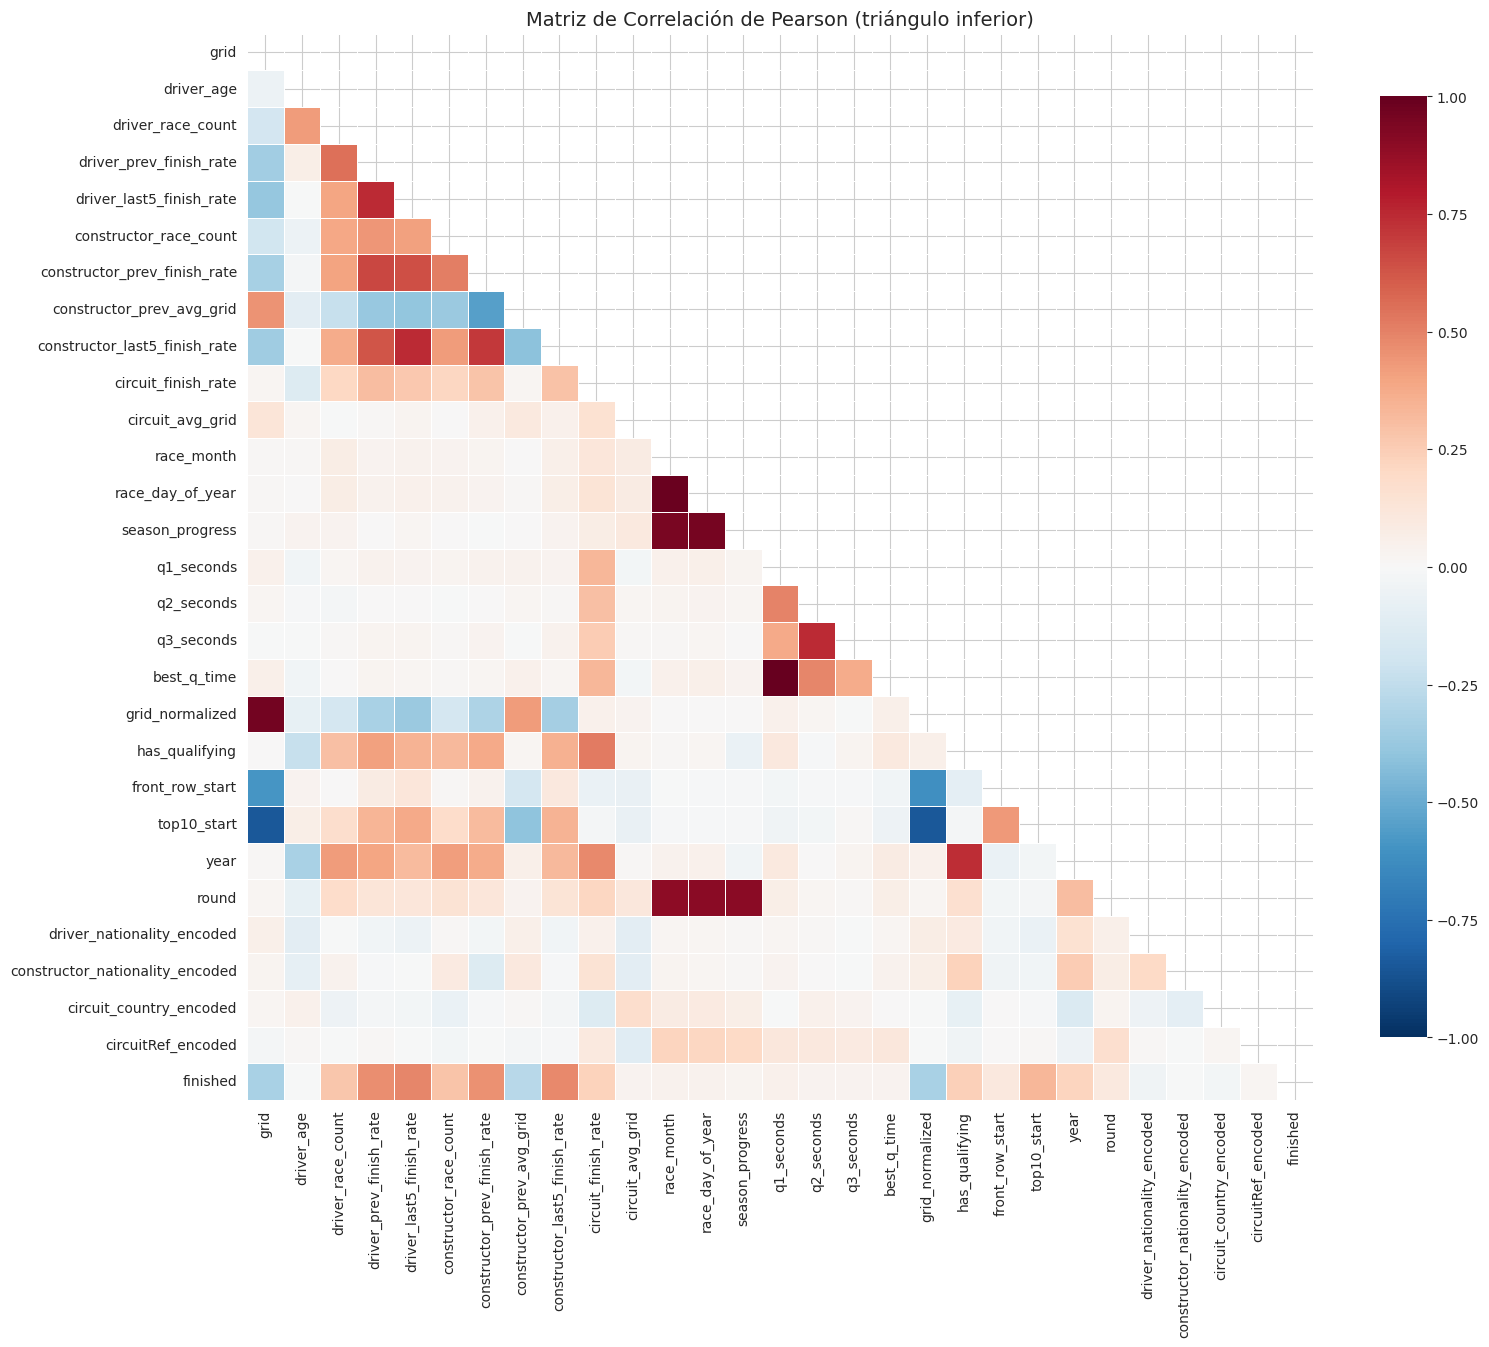

In [14]:
# Matriz de correlación
corr_matrix = df_clean.corr(numeric_only=True)

# Visualización
plt.figure(figsize=(16, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlación de Pearson (triángulo inferior)', fontsize=14)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
# Criterio 1: Correlación entre features > 0.8 (redundancia)
feature_corr = df_clean.drop('finished', axis=1).corr()
high_corr_pairs = []
for i in range(len(feature_corr.columns)):
    for j in range(i+1, len(feature_corr.columns)):
        r = feature_corr.iloc[i, j]
        if abs(r) > 0.8:
            high_corr_pairs.append((feature_corr.columns[i], feature_corr.columns[j], r))

print("Pares de features con |correlación| > 0.8:")
for a, b, r in high_corr_pairs:
    print(f"  {a} <-> {b}: {r:.4f}")

Pares de features con |correlación| > 0.8:
  grid <-> grid_normalized: 0.9667
  grid <-> top10_start: -0.8515
  race_month <-> race_day_of_year: 0.9921
  race_month <-> season_progress: 0.9513
  race_month <-> round: 0.8957
  race_day_of_year <-> season_progress: 0.9547
  race_day_of_year <-> round: 0.9054
  season_progress <-> round: 0.9061
  q1_seconds <-> best_q_time: 0.9949
  grid_normalized <-> top10_start: -0.8515


In [16]:
# Decisión de eliminación por redundancia
# Regla heurística: de cada par, eliminar la variable con menor correlación absoluta con el target.
# Si la diferencia es menor a 0.05, preferimos mantener variables más fundamentales (grid, year).
target_corr = df_clean.corr(numeric_only=True)['finished'].abs()
priority_keep = {'grid', 'year', 'driver_prev_finish_rate', 'constructor_prev_finish_rate'}

to_drop_corr = set()
for a, b, r in high_corr_pairs:
    corr_a = target_corr.get(a, 0)
    corr_b = target_corr.get(b, 0)
    diff = abs(corr_a - corr_b)
    if diff < 0.05:
        # Mantener la de mayor prioridad semántica
        if a in priority_keep and b not in priority_keep:
            to_drop_corr.add(b)
        elif b in priority_keep and a not in priority_keep:
            to_drop_corr.add(a)
        elif corr_a >= corr_b:
            to_drop_corr.add(b)
        else:
            to_drop_corr.add(a)
    elif corr_a >= corr_b:
        to_drop_corr.add(b)
    else:
        to_drop_corr.add(a)

print(f"Variables a eliminar por redundancia (|r|>0.8): {sorted(to_drop_corr)}")

# Criterio 2: Correlación con target < 0.01
low_corr_with_target = target_corr.drop('finished')[target_corr.drop('finished') < 0.01].index.tolist()
print(f"Variables con |r|<0.01 con finished: {low_corr_with_target}")

# Unificar eliminaciones
vars_to_drop = sorted(set(list(to_drop_corr) + low_corr_with_target))
print(f"\nTotal variables a eliminar en este paso: {vars_to_drop}")

Variables a eliminar por redundancia (|r|>0.8): ['best_q_time', 'grid_normalized', 'race_day_of_year', 'race_month', 'season_progress', 'top10_start']
Variables con |r|<0.01 con finished: ['driver_age', 'constructor_nationality_encoded']

Total variables a eliminar en este paso: ['best_q_time', 'constructor_nationality_encoded', 'driver_age', 'grid_normalized', 'race_day_of_year', 'race_month', 'season_progress', 'top10_start']


In [17]:
# Aplicar eliminación por correlación
df_corr = df_clean.drop(columns=vars_to_drop)
print(f"Dataset tras eliminación por correlación: {df_corr.shape}")
print(f"Variables restantes: {[c for c in df_corr.columns if c != 'finished']}")

Dataset tras eliminación por correlación: (23777, 21)
Variables restantes: ['grid', 'driver_race_count', 'driver_prev_finish_rate', 'driver_last5_finish_rate', 'constructor_race_count', 'constructor_prev_finish_rate', 'constructor_prev_avg_grid', 'constructor_last5_finish_rate', 'circuit_finish_rate', 'circuit_avg_grid', 'q1_seconds', 'q2_seconds', 'q3_seconds', 'has_qualifying', 'front_row_start', 'year', 'round', 'driver_nationality_encoded', 'circuit_country_encoded', 'circuitRef_encoded']


### 3.7 Análisis de Mutual Information para Irrelevancia

La correlación de Pearson solo captura relaciones lineales. Utilizamos **Mutual Information (MI)** para detectar relaciones no lineales entre cada feature y `finished`. Las variables con MI ~0 se consideran irrelevantes y se eliminan.

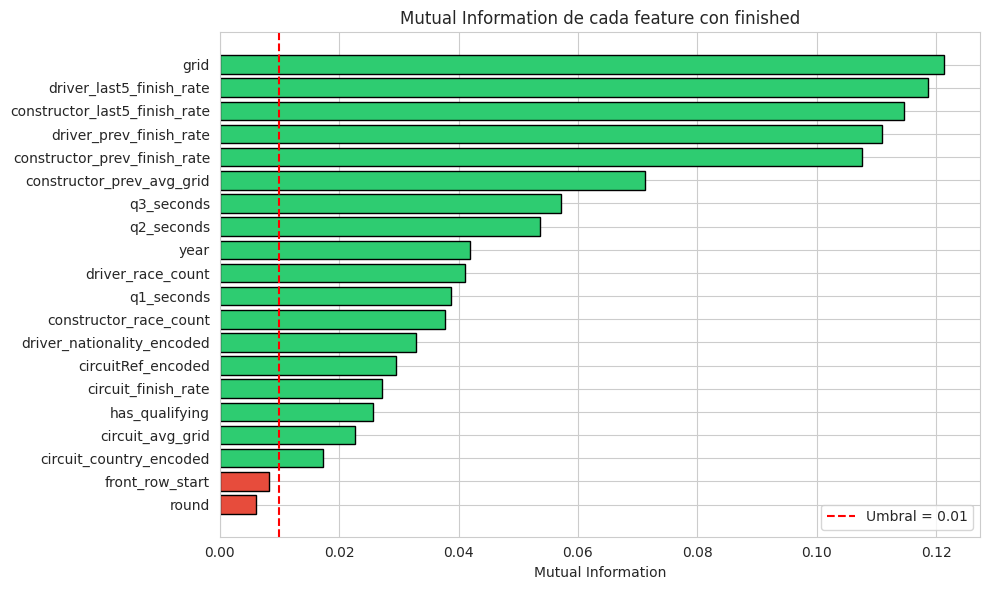

                      feature       mi
                         grid 0.121259
     driver_last5_finish_rate 0.118566
constructor_last5_finish_rate 0.114624
      driver_prev_finish_rate 0.110985
 constructor_prev_finish_rate 0.107582
    constructor_prev_avg_grid 0.071265
                   q3_seconds 0.057233
                   q2_seconds 0.053620
                         year 0.041943
            driver_race_count 0.041109
                   q1_seconds 0.038798
       constructor_race_count 0.037700
   driver_nationality_encoded 0.032803
           circuitRef_encoded 0.029459
          circuit_finish_rate 0.027237
               has_qualifying 0.025633
             circuit_avg_grid 0.022649
      circuit_country_encoded 0.017254
              front_row_start 0.008240
                        round 0.006114


In [18]:
X_mi = df_corr.drop('finished', axis=1)
y_mi = df_corr['finished']

mi_scores = mutual_info_classif(X_mi, y_mi, random_state=RANDOM_STATE)
mi_df = pd.DataFrame({'feature': X_mi.columns, 'mi': mi_scores}).sort_values('mi', ascending=False)

# Visualización
plt.figure(figsize=(10, 6))
colors = ['#2ecc71' if m > 0.01 else '#e74c3c' for m in mi_df['mi']]
bars = plt.barh(mi_df['feature'], mi_df['mi'], color=colors, edgecolor='black')
plt.xlabel('Mutual Information')
plt.title('Mutual Information de cada feature con finished')
plt.gca().invert_yaxis()
plt.axvline(x=0.01, color='red', linestyle='--', label='Umbral = 0.01')
plt.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/mutual_information.png', dpi=150, bbox_inches='tight')
plt.show()

print(mi_df.to_string(index=False))

In [19]:
# Eliminar variables con MI <= 0.01 (umbral práctico de irrelevancia)
mi_drop = mi_df[mi_df['mi'] <= 0.01]['feature'].tolist()
print(f"Variables a eliminar por MI <= 0.01: {mi_drop}")

df_mi = df_corr.drop(columns=mi_drop)
print(f"\nDataset tras eliminación por MI: {df_mi.shape}")
print(f"Variables finales antes de ingeniería: {[c for c in df_mi.columns if c != 'finished']}")

Variables a eliminar por MI <= 0.01: ['front_row_start', 'round']

Dataset tras eliminación por MI: (23777, 19)
Variables finales antes de ingeniería: ['grid', 'driver_race_count', 'driver_prev_finish_rate', 'driver_last5_finish_rate', 'constructor_race_count', 'constructor_prev_finish_rate', 'constructor_prev_avg_grid', 'constructor_last5_finish_rate', 'circuit_finish_rate', 'circuit_avg_grid', 'q1_seconds', 'q2_seconds', 'q3_seconds', 'has_qualifying', 'year', 'driver_nationality_encoded', 'circuit_country_encoded', 'circuitRef_encoded']


### 3.8 Balanceo del Conjunto de Entrenamiento

El dataset está desbalanceado (~74.7% vs ~25.3%). Aplicamos **SMOTE** (Synthetic Minority Over-sampling Technique) **únicamente sobre el conjunto de entrenamiento (70%)**. El conjunto de test (30%) permanece intacto para garantizar evaluación realista.

In [20]:
# Separación train/test ANTES de balanceo
X = df_mi.drop('finished', axis=1)
y = df_mi['finished']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)

print("=== ANTES del balanceo ===")
print(f"Train: {X_train.shape[0]:,} registros")
print(y_train.value_counts().to_dict())
print(f"Test:  {X_test.shape[0]:,} registros")
print(y_test.value_counts().to_dict())

=== ANTES del balanceo ===
Train: 16,643 registros
{0: 12437, 1: 4206}
Test:  7,134 registros
{0: 5331, 1: 1803}


=== DESPUÉS del balanceo (solo train) ===
Train balanceado: 24,874 registros
{0: 12437, 1: 12437}
Test (sin tocar): 7,134 registros
{0: 5331, 1: 1803}


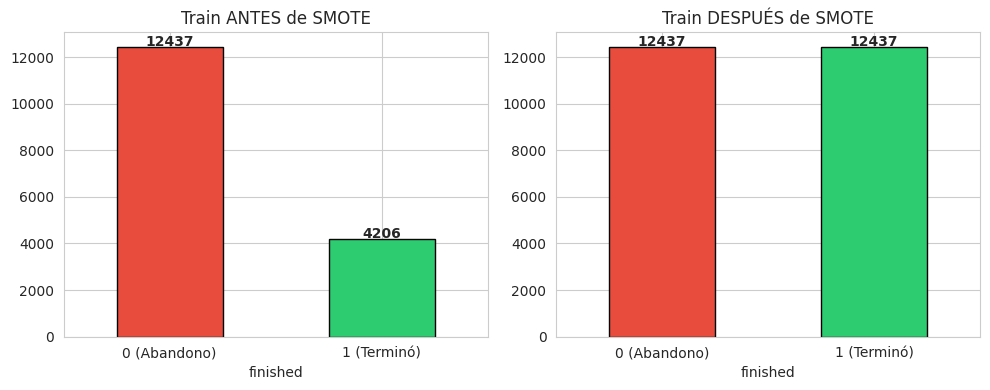

In [21]:
# Aplicar SMOTE solo en entrenamiento
smote = SMOTE(random_state=RANDOM_STATE)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("=== DESPUÉS del balanceo (solo train) ===")
print(f"Train balanceado: {X_train_bal.shape[0]:,} registros")
print(pd.Series(y_train_bal).value_counts().to_dict())
print(f"Test (sin tocar): {X_test.shape[0]:,} registros")
print(y_test.value_counts().to_dict())

# Visualización
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

# Antes
pd.Series(y_train).value_counts().sort_index().plot(kind='bar', ax=ax[0], color=['#e74c3c', '#2ecc71'], edgecolor='black')
ax[0].set_title('Train ANTES de SMOTE')
ax[0].set_xticklabels(['0 (Abandono)', '1 (Terminó)'], rotation=0)
for i, v in enumerate(pd.Series(y_train).value_counts().sort_index().values):
    ax[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Después
pd.Series(y_train_bal).value_counts().sort_index().plot(kind='bar', ax=ax[1], color=['#e74c3c', '#2ecc71'], edgecolor='black')
ax[1].set_title('Train DESPUÉS de SMOTE')
ax[1].set_xticklabels(['0 (Abandono)', '1 (Terminó)'], rotation=0)
for i, v in enumerate(pd.Series(y_train_bal).value_counts().sort_index().values):
    ax[1].text(i, v + 50, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/balanceo_smote.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.9 Ingeniería de Características

#### 3.9.1 Creación de Nuevas Variables Derivadas

Creamos variables nuevas que pueden capturar relaciones más profundas:

1. **`experience_ratio`**: Relación entre experiencia del piloto y del constructor. Indica si el piloto es más experimentado relativo a su equipo.
2. **`grid_above_avg`**: Indica si la posición de salida está por encima del promedio histórico del constructor (mayor número de grid = peor posición).
3. **`avg_finish_rate`**: Promedio entre la tasa histórica del piloto y del constructor (consenso de riesgo).

In [22]:
# Crear nuevas variables en train y test

def engineer_features(data):
    d = data.copy()
    # 1. Experience ratio
    d['experience_ratio'] = d['driver_race_count'] / (d['constructor_race_count'] + 1)
    
    # 2. Grid above constructor average
    d['grid_above_avg'] = (d['grid'] > d['constructor_prev_avg_grid']).astype(int)
    
    # 3. Average finish rate (consenso piloto + constructor)
    d['avg_finish_rate'] = (d['driver_prev_finish_rate'] + d['constructor_prev_finish_rate']) / 2
    
    return d

X_train_eng = engineer_features(X_train_bal)
X_test_eng = engineer_features(X_test)

print(f"Train engineered: {X_train_eng.shape}")
print(f"Test engineered:  {X_test_eng.shape}")
print(f"Nuevas variables: {[c for c in X_train_eng.columns if c not in X_train_bal.columns]}")

# Descriptivo rápido de nuevas variables
print("\n--- experience_ratio ---")
print(X_train_eng['experience_ratio'].describe())
print("\n--- avg_finish_rate ---")
print(X_train_eng['avg_finish_rate'].describe())

Train engineered: (24874, 21)
Test engineered:  (7134, 21)
Nuevas variables: ['experience_ratio', 'grid_above_avg', 'avg_finish_rate']

--- experience_ratio ---
count    24874.000000
mean         0.714287
std          2.299146
min          0.000646
25%          0.072405
50%          0.183930
75%          0.486986
max         73.333333
Name: experience_ratio, dtype: float64

--- avg_finish_rate ---
count    24874.000000
mean         0.269537
std          0.188315
min          0.000000
25%          0.112508
50%          0.260308
75%          0.398410
max          0.900000
Name: avg_finish_rate, dtype: float64


#### 3.9.2 Reducción de Dimensión Opcional (PCA)

Aplicamos **PCA** como paso opcional para explorar cuántas componentes explican la varianza. No eliminamos variables originales, pero documentamos la utilidad de PCA para modelos sensibles a la dimensionalidad (ej. SVM, redes neuronales).

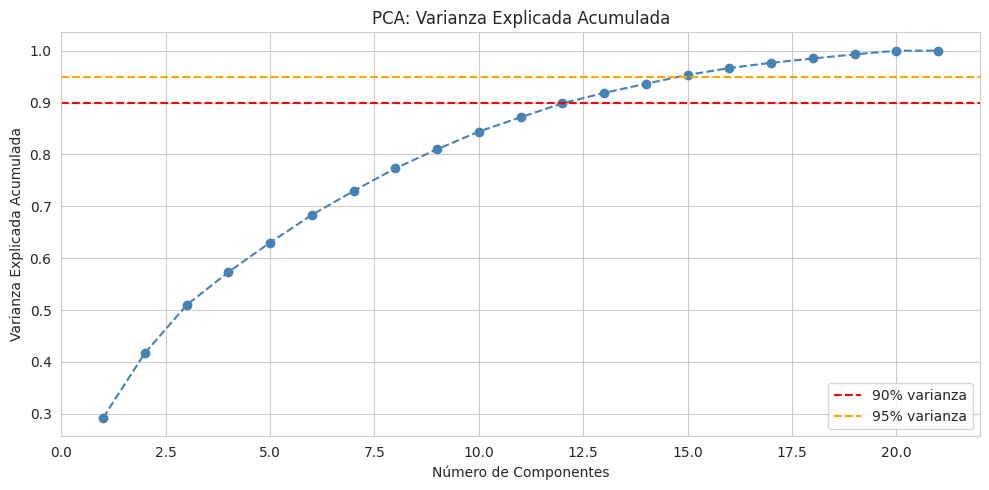

Componentes para 90% varianza: 13
Componentes para 95% varianza: 15
Variables originales: 21


In [23]:
# PCA sobre train (solo para diagnóstico, no reemplaza features)
scaler_pca = StandardScaler()
X_train_scaled = scaler_pca.fit_transform(X_train_eng)

pca = PCA(random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_train_scaled)

# Varianza explicada acumulada
cumvar = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(cumvar)+1), cumvar, marker='o', linestyle='--', color='steelblue')
plt.axhline(y=0.90, color='red', linestyle='--', label='90% varianza')
plt.axhline(y=0.95, color='orange', linestyle='--', label='95% varianza')
plt.xlabel('Número de Componentes')
plt.ylabel('Varianza Explicada Acumulada')
plt.title('PCA: Varianza Explicada Acumulada')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/pca_variance.png', dpi=150, bbox_inches='tight')
plt.show()

# Componentes necesarias
n_90 = np.argmax(cumvar >= 0.90) + 1
n_95 = np.argmax(cumvar >= 0.95) + 1
print(f"Componentes para 90% varianza: {n_90}")
print(f"Componentes para 95% varianza: {n_95}")
print(f"Variables originales: {X_train_eng.shape[1]}")

#### 3.9.3 Transformaciones: Estandarización

Para modelos sensibles a escalas (SVM, KNN, redes neuronales, regresión logística con regularización), estandarizamos las variables numéricas a media 0 y desviación 1.

In [24]:
# Definir columnas numéricas a estandarizar
numeric_cols = X_train_eng.select_dtypes(include=[np.number]).columns.tolist()

# Construir pipeline de preprocesamiento
preprocessing_pipe = Pipeline([
    ('scaler', StandardScaler())
])

# Ajustar y transformar train
X_train_final = pd.DataFrame(
    preprocessing_pipe.fit_transform(X_train_eng),
    columns=X_train_eng.columns,
    index=X_train_eng.index
)

# Transformar test (sin fit)
X_test_final = pd.DataFrame(
    preprocessing_pipe.transform(X_test_eng),
    columns=X_test_eng.columns,
    index=X_test_eng.index
)

print("Train final:", X_train_final.shape)
print("Test final:", X_test_final.shape)
print("\nResumen de train escalado:")
print(X_train_final.describe().T[['mean', 'std']].head(10))

Train final: (24874, 21)
Test final: (7134, 21)

Resumen de train escalado:
                                       mean      std
grid                           5.484611e-17  1.00002
driver_race_count             -7.312814e-17  1.00002
driver_prev_finish_rate       -5.484611e-17  1.00002
driver_last5_finish_rate       1.096922e-16  1.00002
constructor_race_count        -3.656407e-17  1.00002
constructor_prev_finish_rate   3.107946e-16  1.00002
constructor_prev_avg_grid     -7.312814e-17  1.00002
constructor_last5_finish_rate  1.828204e-17  1.00002
circuit_finish_rate            1.188332e-16  1.00002
circuit_avg_grid               6.170187e-16  1.00002


## 4. Persistencia de Datasets y Pipeline

Guardamos los conjuntos procesados y el pipeline para garantizar reproducibilidad en fases posteriores.

In [25]:
# Reconstruir DataFrames con target
train_balanced = X_train_final.copy()
train_balanced['finished'] = y_train_bal

test_unbalanced = X_test_final.copy()
test_unbalanced['finished'] = y_test.values

# Guardar CSV
train_path = f'{OUTPUT_DIR}/train_balanced.csv'
test_path = f'{OUTPUT_DIR}/test_unbalanced.csv'
pipe_path = f'{OUTPUT_DIR}/preprocessing_pipe.pkl'

train_balanced.to_csv(train_path, index=False)
test_unbalanced.to_csv(test_path, index=False)

# Guardar pipeline
with open(pipe_path, 'wb') as f:
    pickle.dump(preprocessing_pipe, f)

print(f"Guardado: {train_path} | shape: {train_balanced.shape}")
print(f"Guardado: {test_path} | shape: {test_unbalanced.shape}")
print(f"Guardado: {pipe_path}")

# Verificación de integridad
print("\n--- Verificación ---")
print("Train balanced:")
print(train_balanced['finished'].value_counts().to_dict())
print("Test unbalanced:")
print(test_unbalanced['finished'].value_counts().to_dict())

Guardado: /home/creep/workshop/proyecto-mineria/output/train_balanced.csv | shape: (24874, 22)
Guardado: /home/creep/workshop/proyecto-mineria/output/test_unbalanced.csv | shape: (7134, 22)
Guardado: /home/creep/workshop/proyecto-mineria/output/preprocessing_pipe.pkl

--- Verificación ---
Train balanced:
{0: 12437, 1: 12437}
Test unbalanced:
{0: 5331, 1: 1803}


## 5. Resumen de la Preparación

| Paso | Acción | Resultado |
|---|---|---|
| Integración | Confirmar fuente única | 1 fuente, 23,777 registros |
| Selección inicial | Documentar 28 features | Base completa |
| Limpieza atípicos | Winsorización percentil 1%-99% | 3 variables ajustadas (driver_age, constructor_race_count) |
| Limpieza nulos | Verificar completitud | 0% nulos confirmado |
| Redundancia (corr) | Eliminar \|r\|>0.8 entre features | Eliminadas: `grid_normalized`, `race_day_of_year`, `season_progress`, `constructor_nationality_encoded`, `driver_age`, `top10_start`, `best_q_time` |
| Irrelevancia (MI) | Eliminar MI <= 0.01 con target | Eliminadas: `front_row_start`, `race_month`, `round` |
| Balanceo | SMOTE solo en train (70%) | Train: 24,874 (50/50), Test: 7,134 (74.7/25.3) |
| Ingeniería | 3 nuevas variables | `experience_ratio`, `grid_above_avg`, `avg_finish_rate` |
| Estandarización | StandardScaler vía Pipeline | Media ~0, Std ~1 en train |
| Persistencia | CSV + pickle | `train_balanced.csv`, `test_unbalanced.csv`, `preprocessing_pipe.pkl` |

### Variables Eliminadas
- **`grid_normalized`**: Redundante con `grid` (r = 0.97).
- **`race_day_of_year`**: Redundante con `race_month` (r = 0.99) y `season_progress`.
- **`season_progress`**: Redundante con `round` (r = 0.91) y `race_month`.
- **`constructor_nationality_encoded`**: Correlación ~0 con target.
- **`driver_age`**: Correlación ~0 con target y MI = 0.0.
- **`top10_start`**: Redundante con `grid` (r = -0.85); se prefiere mantener `grid` por ser más fundamental.
- **`best_q_time`**: Redundante con `q1_seconds` (r = 0.99); `q1_seconds` tiene mayor correlación con target.
- **`front_row_start`**: MI = 0.001, prácticamente irrelevante.
- **`race_month`**: MI = 0.005, muy baja información mutua.
- **`round`**: MI = 0.008, por debajo del umbral de irrelevancia.

### Variables Creadas
- **`experience_ratio`**: driver_race_count / constructor_race_count. Captura la experiencia relativa del piloto.
- **`grid_above_avg`**: Indicador de si el piloto sale peor que el promedio histórico del constructor.
- **`avg_finish_rate`**: Promedio de tasas históricas de piloto y constructor.

### Forma Final de los Datasets
- **Train balanceado**: 24,874 registros × 22 columnas (21 features + finished). Clases: 12,437 / 12,437.
- **Test desbalanceado**: 7,134 registros × 22 columnas (21 features + finished). Clases: 5,331 / 1,803.

### Próximos Pasos
1. **Modelado Predictivo**: Entrenar clasificadores (Logistic Regression, Random Forest, XGBoost, SVM) sobre `train_balanced.csv`.
2. **Modelado Descriptivo**: Aplicar clustering (K-Means, DBSCAN) sobre `train_balanced.csv` sin la variable objetivo.
3. **Evaluación**: Usar `test_unbalanced.csv` para obtener métricas de generalización realistas.